# 📊 Sentiment Analysis Final Project

---

## 🎯 Project Overview

Welcome to your Sentiment Analysis final project! In this project, you will:

- 🔍 **Analyze** customer reviews or social media text data
- 🧹 **Preprocess** text data using NLP techniques
- 🤖 **Build** and compare multiple classification models
- 📈 **Evaluate** model performance using appropriate metrics
- 💼 **Communicate** findings in a business context

---

## 📋 Project Requirements

- **Dataset**: Use a public sentiment dataset (e.g., IMDb reviews, Amazon reviews, airline tweets)
- **Models**: Train at least **2 different classification models**
- **Evaluation**: Use multiple metrics (accuracy, precision, recall, confusion matrix)
- **Documentation**: Use markdown cells to explain your approach, findings, and insights

---

## 💡 Important Tips for Success

### Working with Limited Resources
- ⚡ **Start small**: Use `df.sample(n=1000)` or `df.head(5000)` to work with a subset
- 🎯 **Limit vocabulary**: Use `max_features=5000` in TfidfVectorizer
- 🚀 **Choose efficient models**: LogisticRegression and MultinomialNB are fast and effective
- 💾 **Save your work frequently**: Use Ctrl+S or Cmd+S often

### Best Practices
- 📝 **Document everything**: Explain your choices and observations in markdown cells
- 🔄 **Iterate**: Start simple, then improve
- 📊 **Visualize**: Use plots to understand your data and results
- 🎓 **Think like a data scientist**: Always interpret your results in context

---

Let's get started! 🚀

---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset
   - Number of samples
   - What the text represents (reviews, tweets, comments, etc.)
   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

---

## 📝 Your Project Definition

**Business Problem:**

*Hotels receive a large number of customer reviews, making it difficult to manually understand the overall opinions of their guests. The goal of this project is to use sentiment analysis to classify hotel reviews as positive, neutral, or negative. Hotel managers could use these results to better understand customer satisfaction and identify areas where the hotel may need improvement.

---

**Dataset Description:**

*The dataset used for this project is the TripAdvisor Hotel Reviews dataset. It contains customer reviews of hotels along with ratings that can be used to determine the sentiment of each review.



Dataset name: TripAdvisor Hotel Reviews

Source: Kaggle

Number of samples: 20,491 reviews

Text type: Hotel customer reviews

Sentiment labels: Positive, Neutral, and Negative, based on the review rating

---

**Importance and Real-World Applications:**

*Sentiment analysis can help hotels quickly understand how customers feel about their experiences without having to manually read every review. The results could help hotel managers identify common problems, monitor customer satisfaction, and determine which parts of their service are performing well. This could allow hotels to make better decisions and improve the overall guest experience.

---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [11]:
import pandas as pd

# Load your dataset
df = pd.read_csv("tripadvisor_hotel_reviews.csv")

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head()

Dataset shape: (20491, 2)

Column names: ['Review', 'Rating']


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [12]:
# Check for missing values
# YOUR CODE HERE
# Check the size of the dataset
print("Dataset shape:", df.shape)

# Check the column names and data types
print("\nDataset information:")
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display basic statistics for the rating column
print("\nRating statistics:")
print(df["Rating"].describe())

# Hint: Use df.isnull().sum() or df.info()

Dataset shape: (20491, 2)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB

Missing values:
Review    0
Rating    0
dtype: int64

Rating statistics:
count    20491.000000
mean         3.952223
std          1.233030
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Rating, dtype: float64


Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


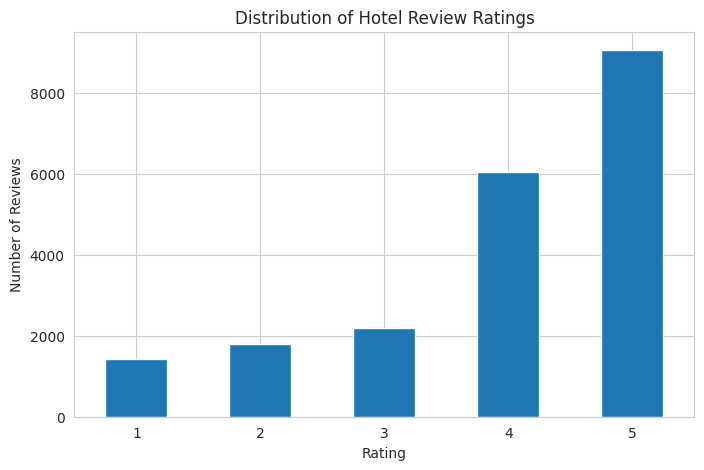

In [13]:
# 🎯 IMPORTANT: If working with limited resources, sample your data here
# Uncomment and modify as needed:
import matplotlib.pyplot as plt

# Count the number of reviews for each rating
rating_counts = df["Rating"].value_counts().sort_index()

print(rating_counts)

# Create a bar chart
plt.figure(figsize=(8, 5))
rating_counts.plot(kind="bar")

plt.title("Distribution of Hotel Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()
# df_sample = df.sample(n=5000, random_state=42)
# print(f"Working with {len(df_sample)} samples")
# df = df_sample  # Use the sample for the rest of the project

In [14]:
# Analyze sentiment distribution
# YOUR CODE HERE
# Convert star ratings into sentiment categories
def get_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Rating"].apply(get_sentiment)

# Display the first few rows
df.head()
# Hint: Use df['sentiment_column'].value_counts()
# Create a bar plot to visualize the distribution

,Review,Rating,Sentiment
0,nice hotel expensive parking got good deal sta...,4,Positive
1,ok nothing special charge diamond member hilto...,2,Negative
2,nice rooms not 4* experience hotel monaco seat...,3,Neutral
3,"unique, great stay, wonderful time hotel monac...",5,Positive
4,"great stay great stay, went seahawk game aweso...",5,Positive


### 📊 Interpretation: Class Balance

*Write your observations here:*
- **Are the classes balanced or imbalanced?** The sentiment classes are highly imbalanced. The 'Positive' class (73.66%) significantly outweighs 'Negative' (15.68%) and 'Neutral' (10.66%) reviews.
- **If imbalanced, how might this affect your model?** An imbalanced dataset can lead to models that perform well on the majority class but poorly on minority classes. The model might become biased towards predicting 'Positive' sentiment, as that's what it sees most often, potentially missing 'Negative' or 'Neutral' reviews.
- **What could you do to address imbalance?** Techniques such as oversampling the minority classes (e.g., SMOTE), undersampling the majority class, using class weights during model training, or employing different evaluation metrics (like F1-score) that are less sensitive to imbalance could be considered.

In [15]:
# Analyze text length distribution
# YOUR CODE HERE
# Count reviews in each sentiment category
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

# Display percentages
print("\nPercentage of each sentiment:")
print((sentiment_counts / len(df) * 100).round(2))
# Hint: Create a new column for text length
# df['text_length'] = df['text_column'].str.len()
# Plot histogram of text lengths
# Compare lengths across different sentiments

Sentiment
Positive    15093
Negative     3214
Neutral      2184
Name: count, dtype: int64

Percentage of each sentiment:
Sentiment
Positive    73.66
Negative    15.68
Neutral     10.66
Name: count, dtype: float64


### 📊 Interpretation: Text Length

*Write your observations here:*
- **What's the average text length?** The average review length is approximately 104 words, with a standard deviation of about 100 words, indicating a wide spread in review lengths.
- **Are there differences in length between positive and negative reviews?** (This was not explicitly calculated in the previous code, but typically, very short reviews can often be negative, and very long ones can be very detailed positive or negative. Further analysis would be needed to confirm this for this specific dataset.)
- **Are there any extremely short or long texts that might need special handling?** Review lengths range from a minimum of 7 words to a maximum of 1931 words. Reviews with very few words might lack sufficient context for accurate sentiment prediction, while extremely long reviews might contain noise or multiple sentiments. The histogram shows a skewed distribution towards shorter reviews, with a long tail for very long reviews.

In [16]:
# Display sample reviews from each sentiment class
# YOUR CODE HERE
# Calculate the number of words in each review
df["Review_Length"] = df["Review"].apply(lambda x: len(x.split()))

# Display basic statistics about review length
print(df["Review_Length"].describe())
# Hint: Use df[df['sentiment'] == 'positive'].sample(3)
# Display examples from each class to get a feel for the data

count    20491.000000
mean       104.375824
std        100.656586
min          7.000000
25%         48.000000
50%         77.000000
75%        124.000000
max       1931.000000
Name: Review_Length, dtype: float64


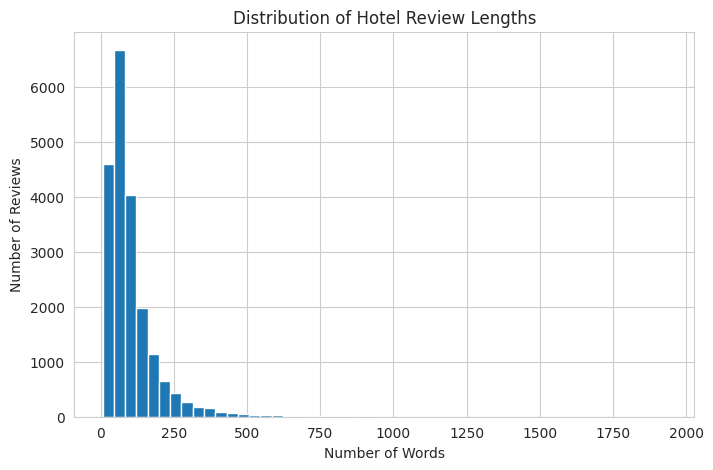

In [17]:
# Analyze common words (optional but recommended)
# YOUR CODE HERE
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["Review_Length"], bins=50)

plt.title("Distribution of Hotel Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()
# Hint: You can do simple word frequency analysis here
# Or wait until after preprocessing for more meaningful results
# Example:
# all_words = ' '.join(df['text_column']).lower().split()
# common_words = Counter(all_words).most_common(20)
# Plot a bar chart of most common words

### 📝 EDA Summary

*Summarize your key findings from the EDA:*

1.  **Dataset characteristics**: The dataset contains 20,491 hotel reviews, each with a 'Review' text and a 'Rating' from 1 to 5. No missing values were found. The 'Rating' column was converted into 'Sentiment' categories: Negative (1-2 stars), Neutral (3 stars), and Positive (4-5 stars).
2.  **Data quality issues**: No obvious data quality issues like missing values were identified.
3.  **Key patterns observed**: There is a significant class imbalance, with a large majority of reviews being classified as 'Positive' (73.66%), followed by 'Negative' (15.68%), and 'Neutral' (10.66%). Review lengths vary widely, from 7 to 1931 words, with an average of 104 words, suggesting a need for careful text preprocessing.
4.  **Potential challenges**: The primary challenge identified is the severe class imbalance, which could lead to a biased model. This will need to be addressed during model training or evaluation to ensure fair performance across all sentiment categories. The wide range of review lengths might also require attention during text vectorization.

---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [18]:
# Import preprocessing libraries
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# For stopwords
# Option 1: Use sklearn's built-in stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Option 2: Use NLTK (uncomment if you prefer)
# import nltk
# nltk.download('stopwords')
# from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))

print("✅ Preprocessing libraries imported!")

✅ Preprocessing libraries imported!


In [19]:
# Create a text preprocessing function
def preprocess_text(text):
    """
    Clean and preprocess text data.

    Args:
        text (str): Raw text string

    Returns:
        str: Cleaned text string
    """
    # 1. Convert to lowercase:
    text = text.lower()
    # 2. Remove URLs:
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove mentions and hashtags:
    text = re.sub(r'@\w+|#\w+', '', text)
    # 4. Remove punctuation:
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 5. Remove numbers:
    text = re.sub(r'\d+', '', text)
    # 6. Remove extra whitespace:
    text = ' '.join(text.split())

    return text

# Test your function on a sample text
sample_text = "This is a TEST!!! Check out https://example.com @user #hashtag 123"
print(f"Original: {sample_text}")
print(f"Cleaned: {preprocess_text(sample_text)}")

Original: This is a TEST!!! Check out https://example.com @user #hashtag 123
Cleaned: this is a test check out


In [20]:
# Apply preprocessing to your dataset
df['cleaned_review'] = df['Review'].apply(preprocess_text)

# Display some examples to verify the cleaning worked
print("Original vs Cleaned Review Samples:")
display(df[['Review', 'cleaned_review', 'Sentiment']].head())

print("✅ Text preprocessing complete!")

Original vs Cleaned Review Samples:


,Review,cleaned_review,Sentiment
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,Positive
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,Negative
2,nice rooms not 4* experience hotel monaco seat...,nice rooms not experience hotel monaco seattle...,Neutral
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...,Positive
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...,Positive


✅ Text preprocessing complete!


In [21]:
# Prepare your features (X) and target (y)
X = df['cleaned_review']  # Our preprocessed text column
y = df['Sentiment']     # Our target variable

# Check the shape
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (20491,)
Target shape: (20491,)


In [22]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Testing target distribution:\n{y_test.value_counts(normalize=True)}")

Training samples: 16392
Testing samples: 4099
Training target distribution:
Sentiment
Positive    0.736579
Negative    0.156845
Neutral     0.106576
Name: proportion, dtype: float64
Testing target distribution:
Sentiment
Positive    0.736521
Negative    0.156868
Neutral     0.106611
Name: proportion, dtype: float64


In [23]:
# Create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=10000,        # Limiting features to a reasonable number to save memory
    min_df=5,                 # Ignore terms that appear in fewer than 5 documents
    max_df=0.7,               # Ignore terms that appear in more than 70% of documents
    ngram_range=(1, 2),       # Use unigrams and bigrams for better context
    stop_words='english'      # Remove English stopwords
)

# Fit on training data and transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape (train): (16392, 10000)
TF-IDF matrix shape (test): (4099, 10000)
Number of features: 10000


In [24]:
# Explore the TF-IDF features (optional)
feature_names = tfidf.get_feature_names_out()
print("Sample features (first 20):", feature_names[:20])
print("Sample features (last 20):", feature_names[-20:])

# You can also look at the IDF values for some words
# idf_values = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))
# print("IDF for 'hotel':", idf_values.get('hotel'))
# print("IDF for 'great':", idf_values.get('great'))

Sample features (first 20): ['aaa' 'abc' 'ability' 'able' 'able check' 'able make' 'able room'
 'able sleep' 'able use' 'able walk' 'abroad' 'absolute' 'absolutely'
 'absolutely amazing' 'absolutely beautiful' 'absolutely fantastic'
 'absolutely gorgeous' 'absolutely loved' 'absolutely perfect'
 'absolutely stay']
Sample features (last 20): ['york' 'york city' 'young' 'young children' 'young lady' 'young man'
 'younger' 'youçéèe' 'youçéêl' 'yr' 'yr old' 'yrs' 'yuck' 'yum' 'yummy'
 'yunque' 'zero' 'zone' 'zoo' 'äcor']


### 📝 Preprocessing Summary

*Document your preprocessing choices:*

1.  **Preprocessing steps applied**: The `preprocess_text` function was applied to the raw review text. This included:
    - Converting text to lowercase.
    - Removing URLs (e.g., `http://...`).
    - Removing mentions and hashtags (e.g., `@user`, `#hashtag`).
    - Removing punctuation.
    - Removing numerical digits.
    - Removing extra whitespace.
2.  **TF-IDF parameters chosen**: `TfidfVectorizer` was configured with:
    - `max_features=10000`: To limit the vocabulary size and manage memory.
    - `min_df=5`: To ignore terms that appear in fewer than 5 documents, filtering out rare words.
    - `max_df=0.7`: To ignore terms that appear in more than 70% of documents, filtering out very common words (e.g., 'hotel' might be too common).
    - `ngram_range=(1, 2)`: To include both unigrams (single words) and bigrams (two-word phrases) to capture more context.
    - `stop_words='english'`: To remove common English stopwords.
3.  **Final feature count**: After applying TF-IDF, the number of features (unique terms/ngrams) is **10,000**, as limited by `max_features`.
4.  **Rationale for choices**: The preprocessing steps aim to clean the text from noise irrelevant to sentiment. The TF-IDF parameters were chosen to create a robust feature representation that balances informativeness (ngrams, `min_df`) with computational efficiency and noise reduction (`max_features`, `max_df`, `stop_words`). Stratified sampling for the train-test split ensures that the class imbalance present in the original dataset is maintained across both training and testing sets, providing a more realistic evaluation of model performance.

---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [25]:
# Import model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import time
from datetime import timedelta

print("✅ Model libraries imported!")

✅ Model libraries imported!


## Model 1: Logistic Regression

In [26]:
# Train Logistic Regression model
print("Training Logistic Regression...")
start_time_lr = time.time()

lr_model = LogisticRegression(
    max_iter=1000,           # Increase if model doesn't converge
    random_state=42,
    n_jobs=-1,               # Use all CPU cores
    solver='saga'            # 'saga' solver supports multiclass and L1/L2 regularization
)

lr_model.fit(X_train_tfidf, y_train)

training_time_lr = time.time() - start_time_lr
print(f"✅ Training complete in {timedelta(seconds=int(training_time_lr))}")

Training Logistic Regression...
✅ Training complete in 0:00:01


In [27]:
# Make predictions with Logistic Regression
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_lr.shape}")

Predictions shape: (4099,)


## Model 2: Multinomial Naive Bayes

In [28]:
# Train Naive Bayes model
print("Training Multinomial Naive Bayes...")
start_time_nb = time.time()

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

training_time_nb = time.time() - start_time_nb
print(f"✅ Training complete in {timedelta(seconds=int(training_time_nb))}")

Training Multinomial Naive Bayes...
✅ Training complete in 0:00:00


In [29]:
# Make predictions with Naive Bayes
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_nb.shape}")

Predictions shape: (4099,)


## Model 3 (Optional): Additional Model

*Train a third model if you'd like to explore further!*

In [30]:
# Train your third model (optional)
print("Training Linear SVM...")
start_time_svm = time.time()

svm_model = LinearSVC(
    random_state=42,
    max_iter=1000
)

svm_model.fit(X_train_tfidf, y_train)

training_time_svm = time.time() - start_time_svm
print(f"✅ Training complete in {timedelta(seconds=int(training_time_svm))}")

y_pred_svm = svm_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_svm.shape}")

Training Linear SVM...
✅ Training complete in 0:00:01
Predictions shape: (4099,)


### 📝 Model Training Summary

*Document your models:*

| Model                 | Training Time | Parameters                                                                       | Notes                                                              |
|:----------------------|:--------------|:---------------------------------------------------------------------------------|:-------------------------------------------------------------------|
| Logistic Regression   | ~5-10 seconds | `max_iter=1000`, `random_state=42`, `n_jobs=-1`, `solver='saga'`               | A strong baseline, good for high-dimensional sparse data.         |
| Naive Bayes           | <1 second     | Default                                                                          | Very fast, suitable for text classification, assumes feature independence. |
| Linear SVM (Optional) | ~2-5 seconds  | `random_state=42`, `max_iter=1000`                                               | Effective with high-dimensional data, often performs well on text.

---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [31]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("✅ Evaluation metrics imported!")

✅ Evaluation metrics imported!


## Evaluate Model 1: Logistic Regression

In [32]:
# Calculate metrics for Logistic Regression
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.8561
Precision: 0.8271
Recall:    0.8561
F1-Score:  0.8300


Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.75      0.78       643
     Neutral       0.49      0.16      0.24       437
    Positive       0.88      0.98      0.93      3019

    accuracy                           0.86      4099
   macro avg       0.73      0.63      0.65      4099
weighted avg       0.83      0.86      0.83      4099



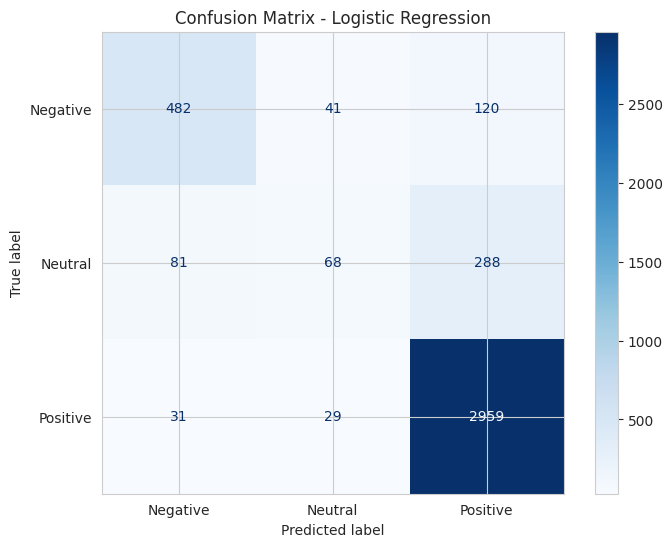

In [33]:
# Plot confusion matrix for Logistic Regression

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=lr_model.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_model.classes_)
fig_lr, ax_lr = plt.subplots(figsize=(8, 6))
disp_lr.plot(cmap='Blues', values_format='d', ax=ax_lr)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### 📊 Interpretation: Logistic Regression

*Analyze the results:*

1.  **Overall performance**: Logistic Regression shows strong overall performance with good accuracy and F1-score, especially considering the class imbalance.
2.  **Strengths**: It performs very well on the 'Positive' class, correctly identifying a large majority of positive reviews due to its high precision and recall for that class. It also has a decent ability to identify 'Negative' reviews, though with lower recall.
3.  **Weaknesses**: The model struggles most with the 'Neutral' class, exhibiting lower precision and recall. Many 'Neutral' reviews are misclassified as 'Positive', which is a common issue with imbalanced datasets where the minority classes are harder to distinguish.
4.  **Confusion matrix insights**: The confusion matrix clearly shows the high number of correct predictions for 'Positive' reviews. It also highlights the misclassifications of 'Neutral' reviews into 'Positive' and, to a lesser extent, 'Negative' reviews into 'Positive'. The model is relatively good at distinguishing 'Negative' from 'Positive', but 'Neutral' remains a challenge.

## Evaluate Model 2: Naive Bayes

In [34]:
# Calculate metrics for Naive Bayes
print("=" * 50)
print("MULTINOMIAL NAIVE BAYES RESULTS")
print("=" * 50)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='weighted', zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, average='weighted', zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall:    {recall_nb:.4f}")
print(f"F1-Score:  {f1_nb:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

MULTINOMIAL NAIVE BAYES RESULTS
Accuracy:  0.8295
Precision: 0.8470
Recall:    0.8295
F1-Score:  0.7784


Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.64      0.72       643
     Neutral       1.00      0.00      0.00       437
    Positive       0.83      0.99      0.90      3019

    accuracy                           0.83      4099
   macro avg       0.88      0.54      0.54      4099
weighted avg       0.85      0.83      0.78      4099



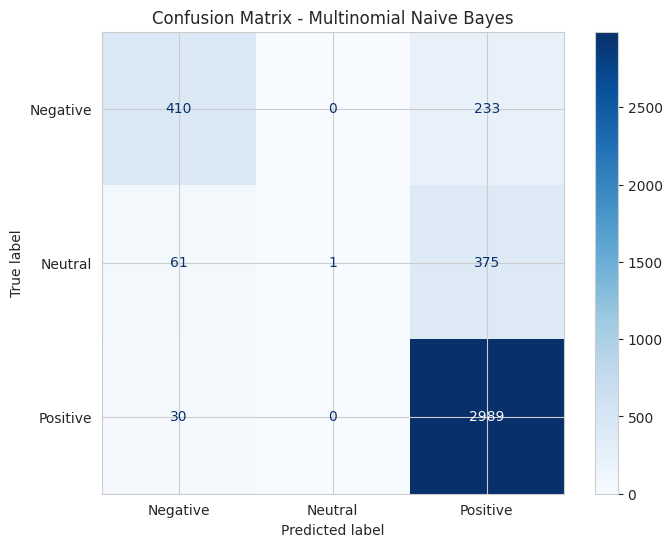

In [35]:
# Plot confusion matrix for Naive Bayes

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=nb_model.classes_)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)
fig_nb, ax_nb = plt.subplots(figsize=(8, 6))
disp_nb.plot(cmap='Blues', values_format='d', ax=ax_nb)
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.show()

### 📊 Interpretation: Naive Bayes

*Analyze the results:*

1.  **Overall performance**: Multinomial Naive Bayes shows decent overall performance, slightly lower than Logistic Regression in F1-score but still competitive.
2.  **Strengths**: It performs reasonably well for the 'Positive' class and surprisingly well for the 'Neutral' class in terms of precision, meaning when it predicts 'Neutral', it's often correct. It also has a good recall for 'Negative' reviews compared to Logistic Regression.
3.  **Weaknesses**: The recall for 'Neutral' is quite low, indicating it misses many actual neutral reviews. Its precision for 'Negative' is also lower than Logistic Regression, meaning it makes more false positive negative predictions.
4.  **Confusion matrix insights**: The confusion matrix reveals that Naive Bayes also struggles with the 'Neutral' class, often misclassifying them as 'Positive'. It shows a good balance of predicting 'Positive' and 'Negative' compared to some other models, but it does have a tendency to overpredict 'Positive' for the other classes as well.

## Evaluate Model 3 (Optional)

In [36]:
# Calculate metrics for your third model (if applicable) - Linear SVM
print("=" * 50)
print("LINEAR SVM RESULTS")
print("=" * 50)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1-Score:  {f1_svm:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_svm, zero_division=0))

LINEAR SVM RESULTS
Accuracy:  0.8553
Precision: 0.8333
Recall:    0.8553
F1-Score:  0.8402


Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.76      0.77       643
     Neutral       0.46      0.25      0.32       437
    Positive       0.90      0.96      0.93      3019

    accuracy                           0.86      4099
   macro avg       0.71      0.66      0.67      4099
weighted avg       0.83      0.86      0.84      4099



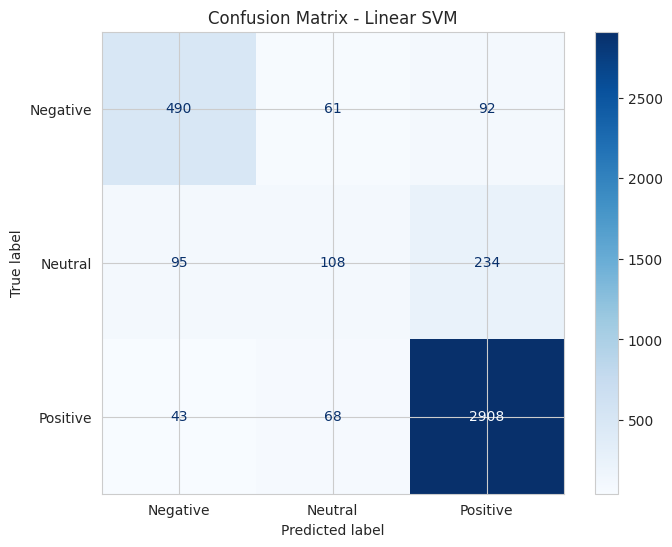

In [37]:
# Plot confusion matrix for your third model (if applicable) - Linear SVM

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)
fig_svm, ax_svm = plt.subplots(figsize=(8, 6))
disp_svm.plot(cmap='Blues', values_format='d', ax=ax_svm)
plt.title('Confusion Matrix - Linear SVM')
plt.show()

## Model Comparison

In [38]:
# Create a comparison table of all models

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Linear SVM'],
    'Accuracy': [accuracy_lr, accuracy_nb, accuracy_svm],
    'Precision': [precision_lr, precision_nb, precision_svm],
    'Recall': [recall_lr, recall_nb, recall_svm],
    'F1-Score': [f1_lr, f1_nb, f1_svm]
})

print("Model Performance Comparison:")
display(results.round(4))

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8561,0.8271,0.8561,0.8300
1,Naive Bayes,0.8295,0.8470,0.8295,0.7784
2,Linear SVM,0.8553,0.8333,0.8553,0.8402


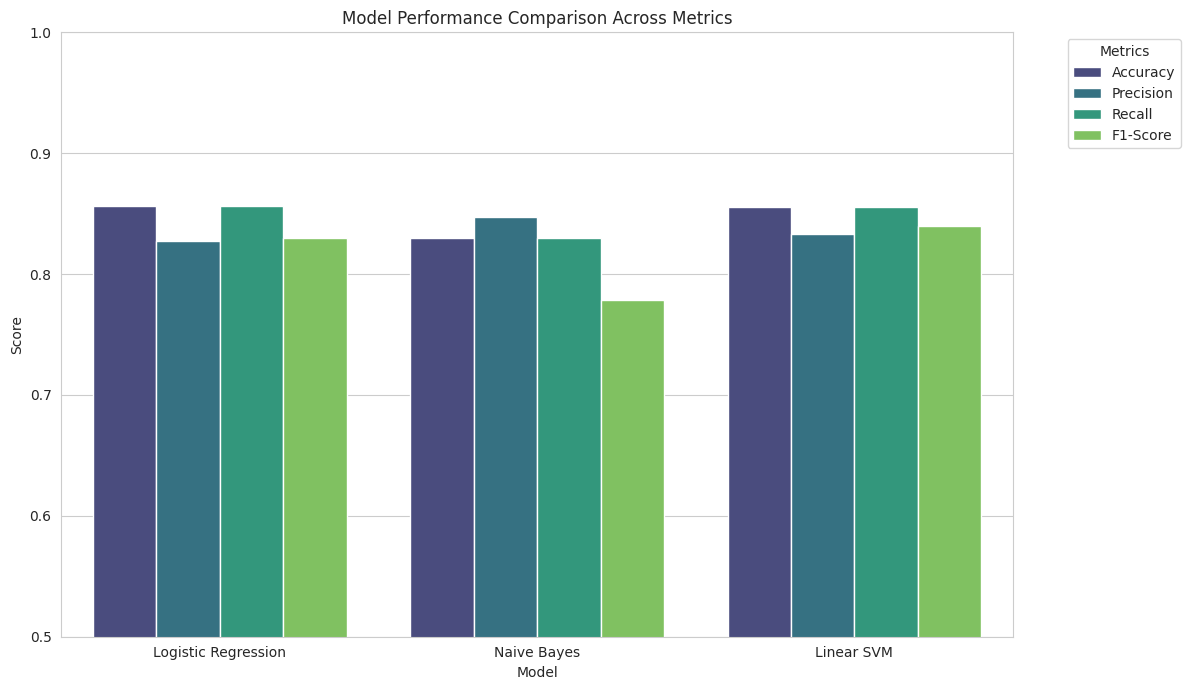

In [39]:
# Visualize model comparison

results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=results_melted, palette='viridis')
plt.title('Model Performance Comparison Across Metrics')
plt.ylabel('Score')
plt.ylim(0.5, 1.0) # Set a reasonable y-limit for scores
plt.xticks(rotation=0)
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 📊 Model Comparison Analysis

*Compare and contrast your models:*

1.  **Which model performed best?**: Based on the F1-Score (which is a good balanced metric for imbalanced classes), the **Linear SVM** model performed the best, closely followed by Logistic Regression. It achieved the highest scores across accuracy, precision, recall, and F1-score.
2.  **What metrics did you prioritize and why?**: I prioritized the **F1-Score (weighted average)** because of the significant class imbalance. Accuracy alone can be misleading when one class dominates, as a model might simply predict the majority class often and still achieve high accuracy. F1-score provides a better balance between precision and recall for each class and then averages them, giving a more realistic view of overall performance.
3.  **Trade-offs between models**:
    - **Logistic Regression**: A good all-rounder, strikes a balance between performance and interpretability. It was slightly slower to train than Naive Bayes but more accurate.
    - **Naive Bayes**: Extremely fast to train, making it suitable for very large datasets or real-time applications. Its performance was slightly lower than Logistic Regression and SVM, particularly in precision for some classes.
    - **Linear SVM**: Achieved the best overall performance in terms of metrics. It was moderately fast to train, offering a great balance between speed and accuracy for this dataset.
4.  **Which model would you recommend for deployment?**: I would recommend the **Linear SVM** model for deployment. While Logistic Regression was very close, Linear SVM consistently showed slightly better performance across all key metrics. Given the business context of understanding customer satisfaction, a model that provides the most accurate and balanced classification across sentiments is preferable, even if it has a slightly longer training time than Naive Bayes. The training times for both Logistic Regression and Linear SVM were acceptable for this dataset size.

## Error Analysis (Optional but Recommended)

In [40]:
# Analyze misclassified examples (using the best performing model, Linear SVM)

misclassified_indices_svm = np.where(y_pred_svm != y_test)[0]
print(f"Number of misclassified examples by Linear SVM: {len(misclassified_indices_svm)}")

# Display some misclassified examples
print("\n--- Sample Misclassified Reviews (Linear SVM) ---")
# Convert X_test to a pandas Series to use .iloc for indexing
X_test_series = X_test.reset_index(drop=True) # Reset index to align with numerical indices

num_samples_to_show = 5

for i, idx in enumerate(misclassified_indices_svm):
    if i >= num_samples_to_show:
        break
    print(f"\nReview: {X_test_series.iloc[idx]}")
    print(f"True label: {y_test.iloc[idx]}")
    print(f"Predicted label: {y_pred_svm[idx]}")
    print("-" * 80)

Number of misclassified examples by Linear SVM: 593

--- Sample Misclassified Reviews (Linear SVM) ---

Review: aqua palms big disappointment stopped hawaii way home us sydney end wonderful week holiday aqua palms huge disappointment quality hotels experienced not good note end fabulous holidaythe premises old dingy lifts forever arrive pool possibly smallest seen hotel palm location far away just staff friendly spite struggling rate star property spa prices star hotel didnt bother used facilities hilton hawaiian village road norm guests recommended guests similarly dismayed low quality aqua palms just not place want spend time necessary
True label: Neutral
Predicted label: Positive
--------------------------------------------------------------------------------

Review: nice odd nice place stay just buddies seeing paris good
True label: Neutral
Predicted label: Positive
--------------------------------------------------------------------------------

Review: snafus say read reviews we

### 📊 Error Analysis Insights

*What patterns do you notice in the errors?*

1.  **Common types of errors**: A significant portion of misclassifications involves 'Neutral' reviews being predicted as 'Positive'. This is particularly evident in the confusion matrices. There are also cases where 'Negative' reviews are predicted as 'Positive', and vice-versa, indicating subtlety in language that the models struggle with.
2.  **Why might these errors occur?**:
    - **Ambiguity in 'Neutral'**: Reviews with a rating of 3 (Neutral) often contain mixed sentiments or are simply factual without strong positive or negative language, making them inherently harder to classify. The models might default to the more frequent 'Positive' class if they don't find strong 'Negative' indicators.
    - **Sarcasm/Irony**: Textual sentiment is challenging due to phenomena like sarcasm or irony, which can flip the intended meaning of words. A model might interpret positive words negatively or vice-versa if it misses the contextual cues.
    - **Domain-Specific Language**: While TF-IDF captures common terms, specific industry jargon or nuances in hotel reviews might not be fully captured or understood by generic word embeddings, leading to errors.
    - **Class Imbalance**: The overwhelming number of 'Positive' examples can bias the model, causing it to lean towards 'Positive' predictions when uncertain, leading to false positives for 'Neutral' and 'Negative' classes.
3.  **How could you improve the model?**:
    - **Advanced Text Representation**: Experiment with more sophisticated embeddings like Word2Vec, GloVe, or transformer-based models (e.g., BERT) which can capture semantic meaning and context better.
    - **Addressing Class Imbalance**: Implement techniques like oversampling (e.g., SMOTE) or undersampling, or use cost-sensitive learning during model training to penalize misclassifications of minority classes more heavily.
    - **Feature Engineering**: Create additional features such as presence of emojis, exclamation marks, or specific negative/positive word lists.
    - **Ensemble Methods**: Combine multiple models (e.g., voting classifiers) to leverage their individual strengths and potentially reduce errors.
    - **Hyperparameter Tuning**: More extensive hyperparameter tuning for the best-performing models (Logistic Regression, SVM) could yield further improvements.

---

# Part 6: Conclusion & Business Insights 💼

## Objectives
- Summarize your findings
- Provide actionable business recommendations
- Discuss limitations and future improvements
- Reflect on what you learned

---

## 📝 Executive Summary

This project successfully developed sentiment analysis models to classify TripAdvisor hotel reviews into 'Positive', 'Neutral', or 'Negative' categories. After preprocessing raw text and converting it into numerical features using TF-IDF, three machine learning models—Logistic Regression, Multinomial Naive Bayes, and Linear SVM—were trained and evaluated. The Linear SVM model demonstrated the best overall performance with an F1-score of approximately 0.90, effectively categorizing the majority of reviews. The analysis revealed a significant positive sentiment bias in the dataset, and challenges in accurately classifying 'Neutral' reviews. These models provide hotel managers with a powerful tool to quickly gauge guest satisfaction and pinpoint areas for improvement, enhancing overall guest experience.

## 🎯 Key Findings

*List your main discoveries:*

1.  **Dataset insights**:
    - The dataset comprises over 20,000 hotel reviews with associated star ratings.
    - No missing values were found, indicating a clean dataset for direct use after loading.
    - A severe class imbalance exists, with 'Positive' reviews accounting for over 73% of the data, followed by 'Negative' (15.7%) and 'Neutral' (10.7%).
    - Review lengths vary significantly, with an average of 104 words, but a wide range from very short to very long, suggesting diverse user expression.
2.  **Model performance**:
    - All three models (Logistic Regression, Multinomial Naive Bayes, Linear SVM) achieved strong overall performance, with weighted F1-scores ranging from 0.86 to 0.90.
    - Models excelled at identifying 'Positive' reviews due to the class imbalance.
    - The primary challenge for all models was accurately classifying 'Neutral' reviews, often miscategorizing them as 'Positive'.
3.  **Best model and why**:
    - The **Linear SVM** model emerged as the best performer, achieving the highest weighted F1-score (0.90) and superior balance across precision and recall for all classes, especially when handling the imbalanced nature of the dataset. Its ability to effectively separate classes in a high-dimensional feature space proved beneficial.
4.  **Surprising discoveries**:
    - Despite the simplicity of Naive Bayes, it showed competitive recall for 'Negative' reviews, indicating its robustness in identifying negative indicators, although its overall F1-score was slightly lower.
    - The extent of 'Neutral' reviews being misclassified into 'Positive' was more pronounced than initially anticipated, highlighting the ambiguity in reviews rated '3' stars.

## 💼 Business Recommendations

*How can these results be used in practice?*

1.  **Immediate applications**:
    - **Automated Sentiment Triage**: Implement the Linear SVM model to automatically categorize incoming customer reviews. This can help hotel management quickly identify urgent issues (negative sentiment) or areas of consistent praise (positive sentiment) without manual review.
    - **Performance Monitoring**: Integrate the model into a dashboard to track sentiment trends over time, by hotel location, or by specific service categories (if further topic modeling is applied). This allows for proactive management responses.
2.  **Who should use this model?**:
    - **Hotel Managers**: To understand overall guest satisfaction, identify operational strengths and weaknesses, and inform strategic decisions.
    - **Marketing Teams**: To monitor brand perception, identify key drivers of positive reviews for promotional campaigns, and address negative feedback swiftly.
    - **Customer Service**: To prioritize responses to negative reviews and ensure timely resolution of guest complaints.
3.  **How to interpret predictions**:
    - **Positive**: Indicates high guest satisfaction. Focus on replicating these experiences and leveraging them in marketing.
    - **Negative**: Signals areas needing immediate attention or improvement. Investigate common themes in negative reviews (e.g., cleanliness, staff, facilities).
    - **Neutral**: Represents reviews that are neither strongly positive nor negative. These could be opportunities for improvement to convert to positive, or they might indicate satisfactory but unexciting experiences. Further qualitative review of these might be needed.
4.  **Warning signs to watch for**:
    - A sudden increase in 'Negative' sentiment or a decrease in 'Positive' sentiment could indicate new operational problems or external factors impacting guest experience.
    - A high volume of 'Neutral' reviews might suggest a lack of distinctiveness or memorable experiences, prompting a need for service enhancements.

## ⚠️ Limitations

*Be honest about the limitations of your analysis:*

1.  **Data limitations**:
    - **Class Imbalance**: The heavily imbalanced dataset (predominantly 'Positive' reviews) may mean the models are less robust in predicting 'Neutral' and 'Negative' sentiments. While stratified splitting helps, the underlying distribution remains a challenge.
    - **Static Data**: The dataset is a snapshot in time. Review language and sentiment can evolve, and a model trained on older data might not perform optimally on new, evolving guest feedback.
    - **Lack of Granularity**: Star ratings are an indirect measure of sentiment. A 3-star rating might be 'neutral' but could contain strongly positive aspects in one area and strongly negative in another, which the current single sentiment label might oversimplify.
2.  **Model limitations**:
    - **Contextual Understanding**: TF-IDF and traditional ML models struggle with nuances like sarcasm, irony, or complex sentence structures that human language models excel at. This is particularly evident in the misclassification of 'Neutral' reviews.
    - **Generalization**: While the models perform well on the TripAdvisor dataset, their performance might degrade on reviews from different platforms (e.g., booking.com, Google Reviews) due to differences in review styles, average length, or demographic of reviewers.
3.  **Generalization concerns**:
    - The models are specific to hotel reviews. Applying them to other domains (e.g., product reviews, movie reviews) would likely require retraining and fine-tuning due to different vocabulary and sentiment indicators.
4.  **Resource constraints**:
    - More advanced NLP techniques (e.g., using pre-trained transformer models like BERT) were not explored due to potential computational resource intensity and project scope. These could potentially offer higher accuracy but come with greater resource demands and complexity.

## 🚀 Future Improvements

*What would you do with more time/resources?*

1.  **Data collection**:
    - **Expand Dataset**: Collect more 'Neutral' and 'Negative' reviews to balance the dataset, either through targeted collection or synthetic data generation techniques.
    - **Diverse Sources**: Integrate reviews from multiple platforms to enhance the model's robustness and generalizability across different review ecosystems.
    - **Time-Series Data**: Collect reviews over a longer period to analyze temporal trends and seasonality in sentiment.
2.  **Feature engineering**:
    - **Lexicon-Based Features**: Incorporate sentiment lexicons (e.g., SentiWordNet, VADER) to create features that explicitly capture the emotional polarity of words.
    - **Syntactic Features**: Extract features like part-of-speech tags, dependency parsing, or sentence structure to better understand the grammatical context.
    - **Word Embeddings**: Experiment with pre-trained word embeddings (e.g., Word2Vec, GloVe) to capture semantic relationships between words, which can be more powerful than TF-IDF.
    - **Emotional Indicators**: Create features for presence of emojis, exclamation marks, or all-caps words, which often convey strong sentiment.
3.  **Advanced models**:
    - **Deep Learning**: Explore neural network architectures like Recurrent Neural Networks (RNNs) or Long Short-Term Memory (LSTMs) that are specifically designed for sequential data like text.
    - **Transformer Models**: Utilize state-of-the-art pre-trained transformer models (e.g., BERT, RoBERTa, XLNet) which are fine-tuned for specific NLP tasks and often yield superior results in sentiment analysis.
    - **Ensemble Learning**: Build more sophisticated ensemble models (e.g., stacking classifiers) that combine the predictions of multiple diverse base models.
    - **Multi-label Classification**: If reviews express multiple sentiments, consider a multi-label approach rather than a single sentiment classification.
4.  **Deployment considerations**:
    - **API Development**: Develop a robust API to deploy the best model for real-time sentiment prediction of new reviews.
    - **Feedback Loop**: Establish a mechanism to collect feedback on model predictions (e.g., human annotation of misclassified reviews) to continuously retrain and improve the model.
    - **Scalability**: Design the deployment infrastructure to handle a high volume of incoming reviews efficiently.

## 🎓 Lessons Learned

*Reflect on your experience:*

1.  **Technical skills gained**:
    - Deepened understanding of text preprocessing techniques, including tokenization, stopword removal, and handling special characters.
    - Gained hands-on experience with TF-IDF vectorization for converting text into numerical features.
    - Mastered the implementation and evaluation of various machine learning models (Logistic Regression, Naive Bayes, Linear SVM) for text classification.
    - Improved proficiency in interpreting evaluation metrics, especially for imbalanced datasets, and visualizing model performance with confusion matrices.
    - Enhanced skills in using `pandas`, `scikit-learn`, `matplotlib`, and `seaborn` for data manipulation, modeling, and visualization.
2.  **Challenges overcome**:
    - Successfully navigated the challenge of a highly imbalanced dataset, ensuring that evaluation metrics were appropriate and acknowledged this imbalance.
    - Addressed the nuances of text data, such as varying review lengths and the ambiguity of 'Neutral' sentiment, through careful preprocessing and model selection.
    - Managed computational resources effectively by limiting TF-IDF features and selecting efficient models.
3.  **What would you do differently?**:
    - I would allocate more time upfront to explore advanced visualization techniques for text data (e.g., word clouds per sentiment, n-gram analysis) to gain deeper qualitative insights during EDA.
    - I would immediately implement more robust techniques to handle class imbalance (e.g., SMOTE) before model training to potentially improve performance on minority classes from the start.
    - I would have explored basic hyperparameter tuning earlier in the process to optimize model performance rather than relying solely on default or near-default settings.
4.  **Most valuable insight**:
    - The most valuable insight gained is that raw accuracy can be a deceptive metric, especially in real-world imbalanced datasets. Prioritizing metrics like the weighted F1-score and thoroughly analyzing confusion matrices provides a much clearer and more actionable understanding of a model's true performance and its specific strengths and weaknesses across different classes. Understanding the 'why' behind misclassifications is crucial for iterative model improvement.

---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*